# reading data vina vs vina

['DecompDiff', 'FLAG', 'MolCraft', 'Pocket2Mol', 'PocketFlow', 'SurfGen', 'TamGen', 'TargetDiff', 'diffSBDD-C', 'diffSBDD-M']


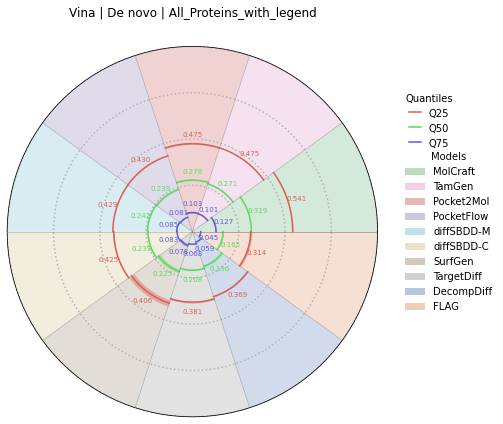

['DecompDiff', 'FLAG', 'MolCraft', 'Pocket2Mol', 'PocketFlow', 'SurfGen', 'TamGen', 'TargetDiff', 'diffSBDD-C', 'diffSBDD-M']


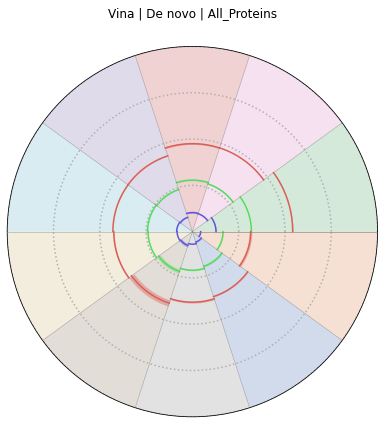

['DecompDiff', 'FLAG', 'MolCraft', 'Pocket2Mol', 'PocketFlow', 'SurfGen', 'TamGen', 'TargetDiff', 'diffSBDD-C', 'diffSBDD-M']


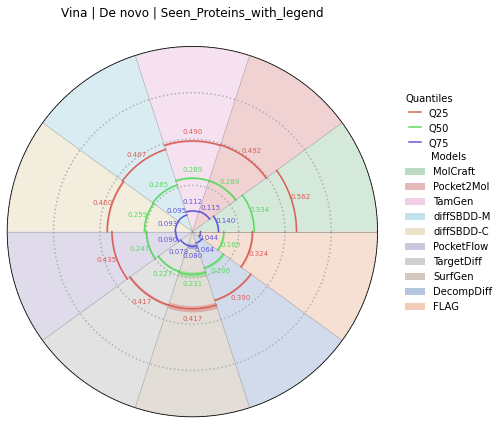

['DecompDiff', 'FLAG', 'MolCraft', 'Pocket2Mol', 'PocketFlow', 'SurfGen', 'TamGen', 'TargetDiff', 'diffSBDD-C', 'diffSBDD-M']


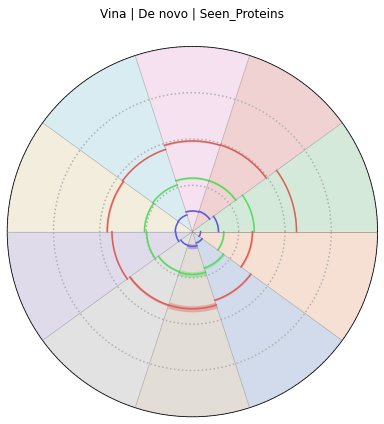

['DecompDiff', 'FLAG', 'MolCraft', 'Pocket2Mol', 'PocketFlow', 'SurfGen', 'TamGen', 'TargetDiff', 'diffSBDD-C', 'diffSBDD-M']


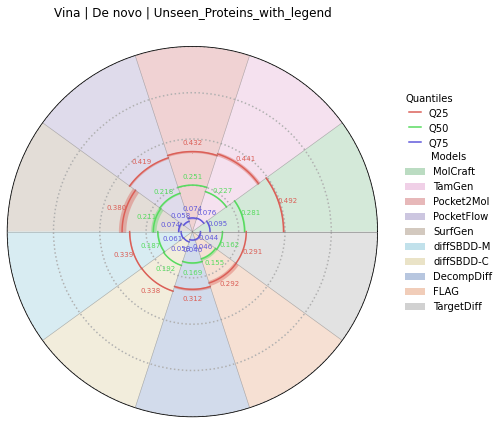

['DecompDiff', 'FLAG', 'MolCraft', 'Pocket2Mol', 'PocketFlow', 'SurfGen', 'TamGen', 'TargetDiff', 'diffSBDD-C', 'diffSBDD-M']


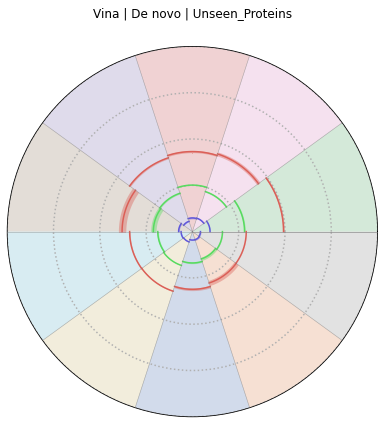

['Delete', 'DiffDec', 'PGMG', 'ShapeMol', 'diffSBDD-C', 'diffSBDD-M', 'shepherd']


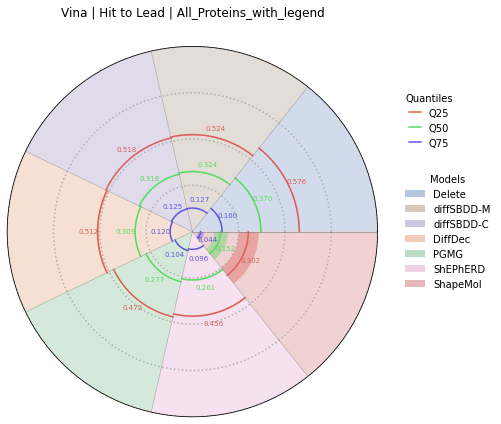

['Delete', 'DiffDec', 'PGMG', 'ShapeMol', 'diffSBDD-C', 'diffSBDD-M', 'shepherd']


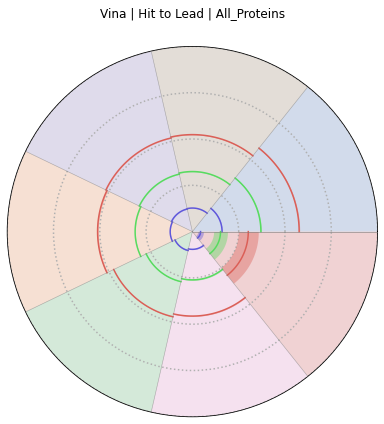

['Delete', 'DiffDec', 'PGMG', 'ShapeMol', 'diffSBDD-C', 'diffSBDD-M', 'shepherd']


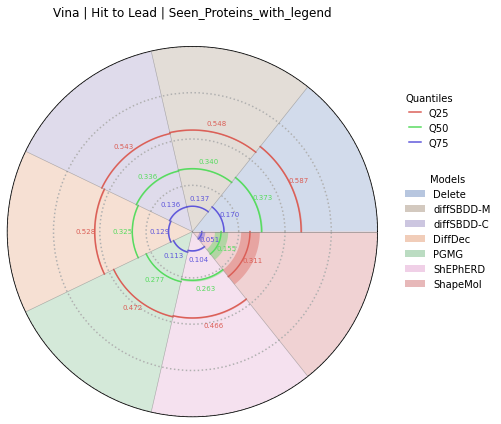

['Delete', 'DiffDec', 'PGMG', 'ShapeMol', 'diffSBDD-C', 'diffSBDD-M', 'shepherd']


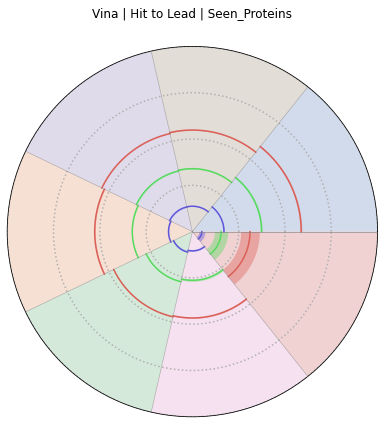

['Delete', 'DiffDec', 'PGMG', 'ShapeMol', 'diffSBDD-C', 'diffSBDD-M', 'shepherd']


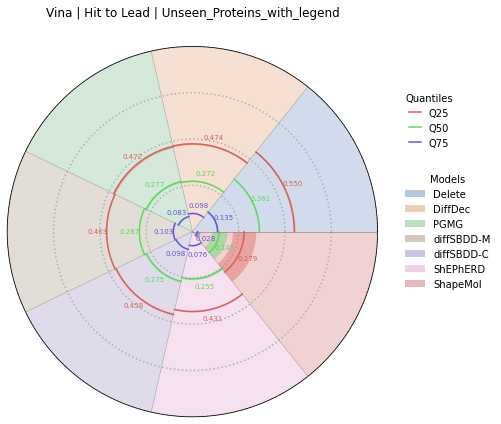

['Delete', 'DiffDec', 'PGMG', 'ShapeMol', 'diffSBDD-C', 'diffSBDD-M', 'shepherd']


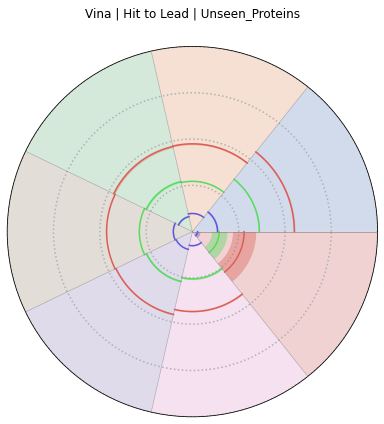

In [ ]:
import os
import pandas as pd
import numpy as np
import yaml
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ========== 数据读取 ==========
data_path = "/home/user-home/fanzhehuan/myprojects/MolGenBench/paper_results"
save_fig_dir = "../final_plot/output/interaction"

round_list = ["Round1", "Round2", "Round3"]
mode_list = ["De_novo_Results", "Hit_to_Lead_Results"]

TASK_LIST_DENOVO = [
    'MolCraft_generated_molecules',
    'DecompDiff_generated_molecules',
    'FLAG_generated_molecules',
    'PocketFlow_generated_molecules',
    'SurfGen_generated_molecules',
    'TargetDiff_generated_molecules',
    'TamGen_generated_molecules',
    "Pocket2Mol_generated_molecules",
    "diffSBDD_cond_crossdocked_generated_molecules",
    "diffSBDD_cond_moad_generated_molecules"
]

DENOVO_NAME_MAPPING = {
    "MolCraft_generated_molecules": "MolCraft",
    "DecompDiff_generated_molecules": "DecompDiff",
    "FLAG_generated_molecules": "FLAG",
    "PocketFlow_generated_molecules": "PocketFlow",
    "SurfGen_generated_molecules": "SurfGen",
    "TargetDiff_generated_molecules": "TargetDiff",
    "TamGen_generated_molecules": "TamGen",
    "Pocket2Mol_generated_molecules": "Pocket2Mol",
    "diffSBDD_cond_crossdocked_generated_molecules": "diffSBDD-C",
    "diffSBDD_cond_moad_generated_molecules": "diffSBDD-M",
}

TASK_LIST_H2L = [
    "DeleteHit2Lead(CrossDock)_Hit_to_Lead",
    "DiffDec_Hit_to_Lead",
    "diffSBDD_cond_crossdocked_Hit_to_Lead",
    "diffSBDD_cond_moad_Hit_to_Lead",
    "PGMG_Hit_to_Lead",
    "ShapeMol_Hit_to_Lead",
    "shepherd_x1x3x4_mosesaq_submission_Hit_to_Lead",
]

H2L_NAME_MAPPING = {
    "DiffDec_Hit_to_Lead": "DiffDec",
    "diffSBDD_cond_crossdocked_Hit_to_Lead": "diffSBDD-C",
    "diffSBDD_cond_moad_Hit_to_Lead": "diffSBDD-M",
    "ShapeMol_Hit_to_Lead": "ShapeMol",
    "shepherd_x1x3x4_mosesaq_submission_Hit_to_Lead": "shepherd",
    "DeleteHit2Lead(CrossDock)_Hit_to_Lead": "Delete",
    "PGMG_Hit_to_Lead": "PGMG",
}


# ========== 读取数据 ==========
results_all = []
results_seen = []
results_unseen = []

for round_name in round_list:
    for mode in mode_list:
        if mode == "De_novo_Results":
            task_list = TASK_LIST_DENOVO
            name_mapping = DENOVO_NAME_MAPPING
            task_type = "De novo"
        else:
            task_list = TASK_LIST_H2L
            name_mapping = H2L_NAME_MAPPING
            task_type = "Hit to Lead"
        
        for task in task_list:
            yaml_path = os.path.join(data_path, round_name, mode, task, "results.yaml")
            if not os.path.exists(yaml_path):
                print(f"Warning: {yaml_path} not found")
                continue
                
            with open(yaml_path, 'r') as f:
                result = yaml.safe_load(f)

                results_all.append({
                    "Model": name_mapping[task],
                    "Round": round_name,
                    "Type": task_type,
                    "InteractionScore>p25": result['metrics']['InteractionScore_docked']['all']['InteractionScore>p25'],
                    "InteractionScore>p50": result['metrics']['InteractionScore_docked']['all']['InteractionScore>p50'],
                    "InteractionScore>p75": result['metrics']['InteractionScore_docked']['all']['InteractionScore>p75'],
                })
                
                results_seen.append({
                    "Model": name_mapping[task],
                    "Round": round_name,
                    "Type": task_type,
                    "InteractionScore>p25": result['metrics']['InteractionScore_docked']['seen']['InteractionScore>p25'],
                    "InteractionScore>p50": result['metrics']['InteractionScore_docked']['seen']['InteractionScore>p50'],
                    "InteractionScore>p75": result['metrics']['InteractionScore_docked']['seen']['InteractionScore>p75'],
                })
                
                results_unseen.append({
                    "Model": name_mapping[task],
                    "Round": round_name,
                    "Type": task_type,
                    "InteractionScore>p25": result['metrics']['InteractionScore_docked']['unseen']['InteractionScore>p25'],
                    "InteractionScore>p50": result['metrics']['InteractionScore_docked']['unseen']['InteractionScore>p50'],
                    "InteractionScore>p75": result['metrics']['InteractionScore_docked']['unseen']['InteractionScore>p75'],
                })

df_results_all = pd.DataFrame(results_all)
df_results_seen = pd.DataFrame(results_seen)
df_results_unseen = pd.DataFrame(results_unseen)


# ========== 转换为 plot_quantile_polar 所需的格式 ==========
def convert_to_polar_stats(df_results, interaction_type="Vina"):
    """
    将 df_results 转换为 plot_quantile_polar 所需的 stats_df 格式
    
    输入格式:
        Model, Round, Type, InteractionScore>p25, InteractionScore>p50, InteractionScore>p75
    
    输出格式 (stats_df):
        interaction_type, model_name, quantile, proportion_above_mean, proportion_above_std
    """
    # 将宽格式转换为长格式
    df_long = df_results.melt(
        id_vars=['Model', 'Round', 'Type'],
        value_vars=['InteractionScore>p25', 'InteractionScore>p50', 'InteractionScore>p75'],
        var_name='quantile_str',
        value_name='proportion_above'
    )
    
    # 映射 quantile 字符串到数值
    quantile_map = {
        'InteractionScore>p25': 0.25,
        'InteractionScore>p50': 0.50,
        'InteractionScore>p75': 0.75
    }
    df_long['quantile'] = df_long['quantile_str'].map(quantile_map)
    
    # 按 Model, Type, quantile 聚合（计算 3 个 Round 的 mean 和 std）
    stats_df = (
        df_long
        .groupby(['Model', 'Type', 'quantile'])['proportion_above']
        .agg(['mean', 'std'])
        .reset_index()
        .rename(columns={
            'Model': 'model_name',
            'mean': 'proportion_above_mean',
            'std': 'proportion_above_std'
        })
    )
    
    # 添加 interaction_type 列
    stats_df['interaction_type'] = interaction_type
    
    # 填充 NaN（如果只有一个 Round，std 会是 NaN）
    stats_df['proportion_above_std'] = stats_df['proportion_above_std'].fillna(0)
    
    return stats_df

def replace_model_name(model_name):
    """模型名称简化"""
    if 'diffSBDD_cond_crossdocked' in model_name:
        return 'DiffSBDD-C'
    elif 'diffSBDD_cond_moad' in model_name:
        return 'DiffSBDD-M'
    elif 'shepherd' in model_name:
        return 'ShEPhERD'
    else:
        return model_name

def plot_quantile_polar(stats_df, interaction_type, task_type="De novo",
                        quantiles=(0.25, 0.50, 0.75),
                        quantile_palette=None, model_order=None, 
                        show_mean_values=True, show_legend=True,
                        title_suffix="R=mean±std(ALL Proteins)"):
    """
    极坐标图：显示每个模型在不同 quantile 下的 proportion_above_mean
    """
    # 筛选指定 interaction_type 和 task_type 的数据
    sub_df = stats_df[
        (stats_df['interaction_type'] == interaction_type) & 
        (stats_df['Type'] == task_type)
    ].copy()
    
    if sub_df.empty:
        print(f"Warning: No data for {interaction_type} - {task_type}")
        return
    
    # 聚合数据
    agg = (sub_df
           .groupby(['model_name', 'quantile'], as_index=False)
           .agg({'proportion_above_mean': 'mean',
                 'proportion_above_std': 'mean'})
        )

    quantiles = list(quantiles)
    if model_order is None:
        first_q = quantiles[0]
        model_order = (agg[agg['quantile'] == first_q]
                       .sort_values('proportion_above_mean', ascending=False)
                       ['model_name'].tolist())

    n_models = len(model_order)
    sector_width = 2 * np.pi / max(n_models, 1)

    if quantile_palette is None:
        quantile_palette = {q: c for q, c in zip(quantiles, sns.color_palette('hls', len(quantiles)))}

    base_palette = sns.color_palette('deep', n_models)
    model_sorted = sorted(model_order)
    print(model_sorted)
    base_color = dict(zip(model_sorted, base_palette))

    fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'polar': True})
    ax.set_xticks([])
    ax.set_rlim(0, 1.0)
    ax.set_rticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels([])
    ax.set_rlabel_position(90)
    ax.grid(alpha=1, linestyle=':', linewidth=1.5)

    # 绘制背景扇形
    for idx, model in enumerate(model_order):
        theta_mid = (idx + 0.5) * sector_width
        ax.bar(theta_mid, 1.0, width=sector_width, bottom=0,
               color=base_color[model], edgecolor='none',
               linewidth=0, alpha=0.25, zorder=0)

    theta_res = 80
    for idx, model in enumerate(model_order):
        theta_start = idx * sector_width
        theta_end = (idx + 1) * sector_width
        theta = np.linspace(theta_start, theta_end, theta_res)

        for q in quantiles:
            row = agg[(agg['model_name'] == model) & (agg['quantile'] == q)]
            if row.empty:
                continue
            mean_r = float(row['proportion_above_mean'].values[0])
            std_r = float(row['proportion_above_std'].values[0])
            mean_r = np.clip(mean_r, 0, 1)
            std_r = max(std_r, 0)

            lower = max(mean_r - std_r, 0.0)
            upper = min(mean_r + std_r, 1.0)

            if std_r > 0:
                ax.fill_between(theta, lower, upper,
                                color=quantile_palette[q],
                                alpha=0.4, linewidth=0, zorder=2)

            ax.plot(theta,
                    np.full_like(theta, mean_r),
                    color=quantile_palette[q],
                    linewidth=1.5,
                    label=f"Q{int(q*100)}" if (idx == 0) else None,
                    zorder=3)

        ax.plot([theta_start, theta_start], [0, 1.0],
                color='gray', linewidth=0.6, alpha=0.6, zorder=5)

        if show_mean_values:
            theta_mid = (theta_start + theta_end) / 2
            for q in quantiles:
                row_q = agg[(agg['model_name'] == model) & (agg['quantile'] == q)]
                if row_q.empty:
                    continue
                m_val = float(row_q['proportion_above_mean'].values[0])
                label_r = min(m_val + 0.05, 0.98)
                if label_r - m_val < 0.03:
                    label_r = max(m_val - 0.05, 0.02)
                ax.text(theta_mid, label_r, f"{m_val:.3f}",
                    ha='center', va='center',
                    fontsize=7, color=quantile_palette[q])

    ax.plot([n_models * sector_width, n_models * sector_width], [0, 1.0],
            color='gray', linewidth=0.6, alpha=0.6, zorder=5)

    ax.set_title(f"{interaction_type} | {task_type} | {title_suffix}", pad=30, fontsize=12)
    
    model_patches = [Patch(facecolor=base_color[m], alpha=0.4, label=replace_model_name(m)) for m in model_order]
    if show_legend:
        fig.subplots_adjust(right=0.80)

        q_legend = ax.legend(loc='center left',
                     bbox_to_anchor=(1.05, 0.8),
                     frameon=False,
                     title='Quantiles',
                     ncol=1,
                     handlelength=1.2,
                     columnspacing=1.0)
        ax.add_artist(q_legend)

        ax.legend(handles=model_patches, loc='center left',
                bbox_to_anchor=(1.05, 0.5),
                frameon=False, title='Models')

    plt.tight_layout()
    os.makedirs(save_fig_dir, exist_ok=True)
    save_name = f'polar_plot_{interaction_type}_{task_type}_{title_suffix}.svg'.replace(' ', '_')
    plt.savefig(f'{save_fig_dir}/{save_name}', bbox_inches='tight', dpi=300, format='svg')
    plt.show()
    plt.close()


# ========== 转换数据并绑图 ==========
# 转换为 stats_df 格式
stats_df_all = convert_to_polar_stats(df_results_all, interaction_type="Vina")
stats_df_seen = convert_to_polar_stats(df_results_seen, interaction_type="Vina")
stats_df_unseen = convert_to_polar_stats(df_results_unseen, interaction_type="Vina")

# ========== De novo 绘图 ==========
# All proteins
plot_quantile_polar(stats_df_all, "Vina", task_type="De novo",
                    title_suffix='All_Proteins_with_legend', show_mean_values=True, show_legend=True)
plot_quantile_polar(stats_df_all, "Vina", task_type="De novo",
                    title_suffix='All_Proteins', show_mean_values=False, show_legend=False)

# Seen proteins
plot_quantile_polar(stats_df_seen, "Vina", task_type="De novo",
                    title_suffix='Seen_Proteins_with_legend', show_mean_values=True, show_legend=True)
plot_quantile_polar(stats_df_seen, "Vina", task_type="De novo",
                    title_suffix='Seen_Proteins', show_mean_values=False, show_legend=False)

# Unseen proteins
plot_quantile_polar(stats_df_unseen, "Vina", task_type="De novo",
                    title_suffix='Unseen_Proteins_with_legend', show_mean_values=True, show_legend=True)
plot_quantile_polar(stats_df_unseen, "Vina", task_type="De novo",
                    title_suffix='Unseen_Proteins', show_mean_values=False, show_legend=False)

# ========== Hit to Lead 绘图 ==========
# All proteins
plot_quantile_polar(stats_df_all, "Vina", task_type="Hit to Lead",
                    title_suffix='All_Proteins_with_legend', show_mean_values=True, show_legend=True)
plot_quantile_polar(stats_df_all, "Vina", task_type="Hit to Lead",
                    title_suffix='All_Proteins', show_mean_values=False, show_legend=False)

# Seen proteins
plot_quantile_polar(stats_df_seen, "Vina", task_type="Hit to Lead",
                    title_suffix='Seen_Proteins_with_legend', show_mean_values=True, show_legend=True)
plot_quantile_polar(stats_df_seen, "Vina", task_type="Hit to Lead",
                    title_suffix='Seen_Proteins', show_mean_values=False, show_legend=False)

# Unseen proteins
plot_quantile_polar(stats_df_unseen, "Vina", task_type="Hit to Lead",
                    title_suffix='Unseen_Proteins_with_legend', show_mean_values=True, show_legend=True)
plot_quantile_polar(stats_df_unseen, "Vina", task_type="Hit to Lead",
                    title_suffix='Unseen_Proteins', show_mean_values=False, show_legend=False)

# raw vs vina in SI

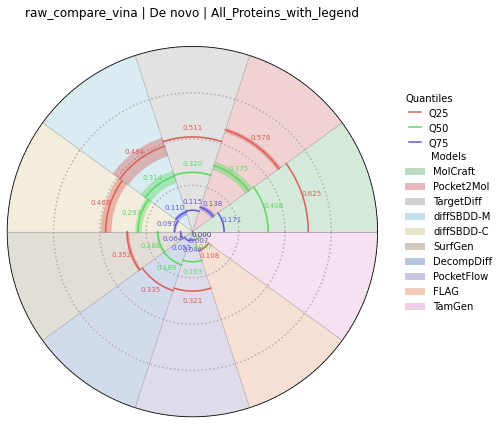

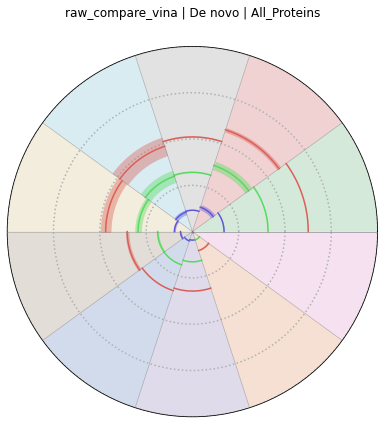

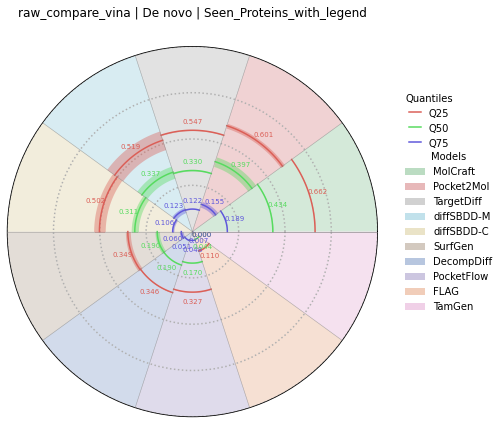

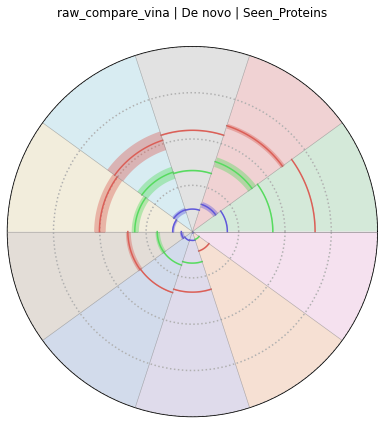

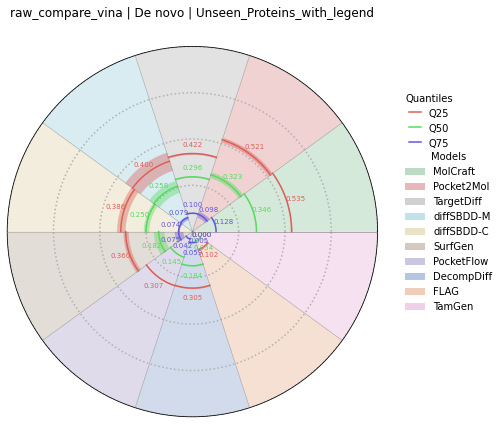

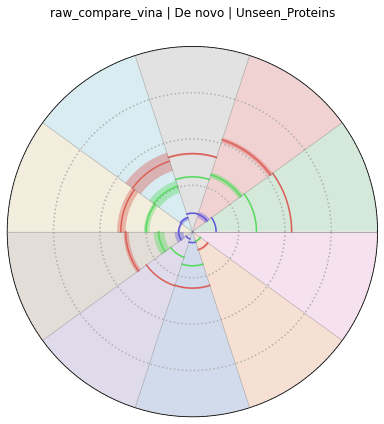

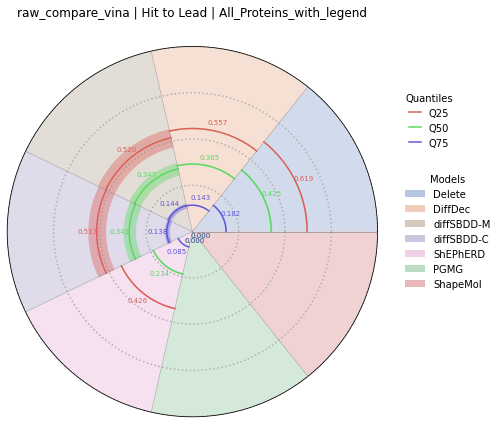

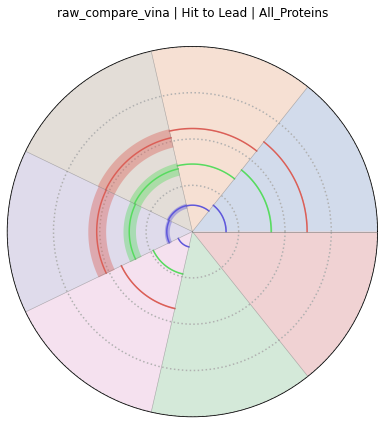

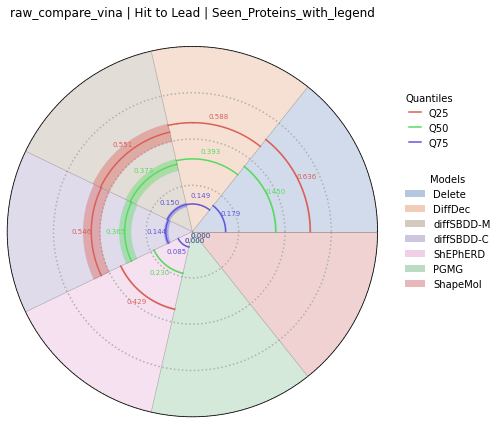

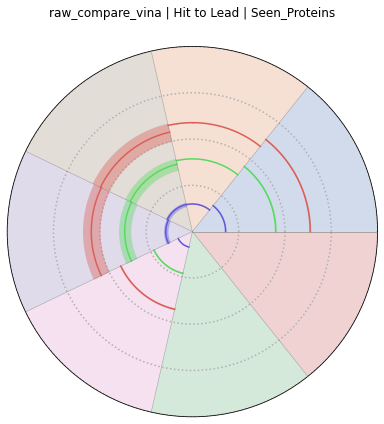

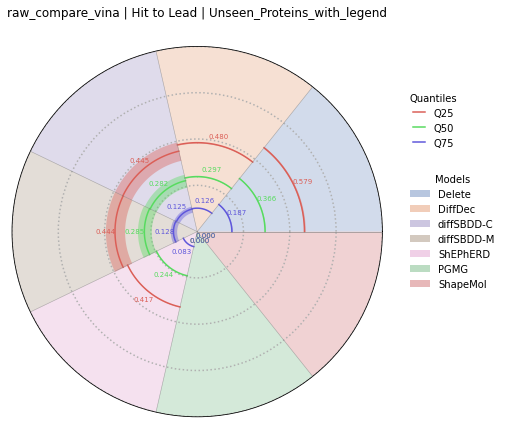

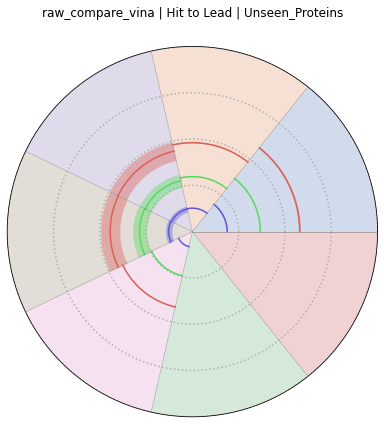

In [ ]:
import os
import pandas as pd
import numpy as np
import yaml
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ========== 数据读取 ==========
data_path = "/home/user-home/fanzhehuan/myprojects/MolGenBench/paper_results"
save_fig_dir = "../final_plot/output/interaction"

round_list = ["Round1", "Round2", "Round3"]
mode_list = ["De_novo_Results", "Hit_to_Lead_Results"]

TASK_LIST_DENOVO = [
    'MolCraft_generated_molecules',
    'DecompDiff_generated_molecules',
    'FLAG_generated_molecules',
    'PocketFlow_generated_molecules',
    'SurfGen_generated_molecules',
    'TargetDiff_generated_molecules',
    'TamGen_generated_molecules',
    "Pocket2Mol_generated_molecules",
    "diffSBDD_cond_crossdocked_generated_molecules",
    "diffSBDD_cond_moad_generated_molecules"
]

DENOVO_NAME_MAPPING = {
    "MolCraft_generated_molecules": "MolCraft",
    "DecompDiff_generated_molecules": "DecompDiff",
    "FLAG_generated_molecules": "FLAG",
    "PocketFlow_generated_molecules": "PocketFlow",
    "SurfGen_generated_molecules": "SurfGen",
    "TargetDiff_generated_molecules": "TargetDiff",
    "TamGen_generated_molecules": "TamGen",
    "Pocket2Mol_generated_molecules": "Pocket2Mol",
    "diffSBDD_cond_crossdocked_generated_molecules": "diffSBDD-C",
    "diffSBDD_cond_moad_generated_molecules": "diffSBDD-M",
}

TASK_LIST_H2L = [
    "DeleteHit2Lead(CrossDock)_Hit_to_Lead",
    "DiffDec_Hit_to_Lead",
    "diffSBDD_cond_crossdocked_Hit_to_Lead",
    "diffSBDD_cond_moad_Hit_to_Lead",
    "PGMG_Hit_to_Lead",
    "ShapeMol_Hit_to_Lead",
    "shepherd_x1x3x4_mosesaq_submission_Hit_to_Lead",
]

H2L_NAME_MAPPING = {
    "DiffDec_Hit_to_Lead": "DiffDec",
    "diffSBDD_cond_crossdocked_Hit_to_Lead": "diffSBDD-C",
    "diffSBDD_cond_moad_Hit_to_Lead": "diffSBDD-M",
    "ShapeMol_Hit_to_Lead": "ShapeMol",
    "shepherd_x1x3x4_mosesaq_submission_Hit_to_Lead": "shepherd",
    "DeleteHit2Lead(CrossDock)_Hit_to_Lead": "Delete",
    "PGMG_Hit_to_Lead": "PGMG",
}


# ========== 读取数据 ==========
results_all = []
results_seen = []
results_unseen = []

for round_name in round_list:
    for mode in mode_list:
        if mode == "De_novo_Results":
            task_list = TASK_LIST_DENOVO
            name_mapping = DENOVO_NAME_MAPPING
            task_type = "De novo"
        else:
            task_list = TASK_LIST_H2L
            name_mapping = H2L_NAME_MAPPING
            task_type = "Hit to Lead"
        
        for task in task_list:
            yaml_path = os.path.join(data_path, round_name, mode, task, "results.yaml")
            if not os.path.exists(yaml_path):
                print(f"Warning: {yaml_path} not found")
                continue
                
            with open(yaml_path, 'r') as f:
                result = yaml.safe_load(f)
                
                # 安全获取 raw_compare_vina 数据，如果不存在则返回默认值 0
                def get_raw_compare_vina(result, split, key):
                    try:
                        return result['metrics']['InteractionScore'][split][key]
                    except (KeyError, TypeError):
                        return 0.0

                results_all.append({
                    "Model": name_mapping[task],
                    "Round": round_name,
                    "Type": task_type,
                    "InteractionScore>p25": get_raw_compare_vina(result, 'all', 'InteractionScore>p25'),
                    "InteractionScore>p50": get_raw_compare_vina(result, 'all', 'InteractionScore>p50'),
                    "InteractionScore>p75": get_raw_compare_vina(result, 'all', 'InteractionScore>p75'),
                })
                
                results_seen.append({
                    "Model": name_mapping[task],
                    "Round": round_name,
                    "Type": task_type,
                    "InteractionScore>p25": get_raw_compare_vina(result, 'seen', 'InteractionScore>p25'),
                    "InteractionScore>p50": get_raw_compare_vina(result, 'seen', 'InteractionScore>p50'),
                    "InteractionScore>p75": get_raw_compare_vina(result, 'seen', 'InteractionScore>p75'),
                })
                
                results_unseen.append({
                    "Model": name_mapping[task],
                    "Round": round_name,
                    "Type": task_type,
                    "InteractionScore>p25": get_raw_compare_vina(result, 'unseen', 'InteractionScore>p25'),
                    "InteractionScore>p50": get_raw_compare_vina(result, 'unseen', 'InteractionScore>p50'),
                    "InteractionScore>p75": get_raw_compare_vina(result, 'unseen', 'InteractionScore>p75'),
                })

df_results_all = pd.DataFrame(results_all)
df_results_seen = pd.DataFrame(results_seen)
df_results_unseen = pd.DataFrame(results_unseen)


# ========== 转换为 plot_quantile_polar 所需的格式 ==========
def convert_to_polar_stats(df_results, interaction_type="Vina"):
    """
    将 df_results 转换为 plot_quantile_polar 所需的 stats_df 格式
    """
    df_long = df_results.melt(
        id_vars=['Model', 'Round', 'Type'],
        value_vars=['InteractionScore>p25', 'InteractionScore>p50', 'InteractionScore>p75'],
        var_name='quantile_str',
        value_name='proportion_above'
    )
    
    quantile_map = {
        'InteractionScore>p25': 0.25,
        'InteractionScore>p50': 0.50,
        'InteractionScore>p75': 0.75
    }
    df_long['quantile'] = df_long['quantile_str'].map(quantile_map)
    
    stats_df = (
        df_long
        .groupby(['Model', 'Type', 'quantile'])['proportion_above']
        .agg(['mean', 'std'])
        .reset_index()
        .rename(columns={
            'Model': 'model_name',
            'mean': 'proportion_above_mean',
            'std': 'proportion_above_std'
        })
    )
    
    stats_df['interaction_type'] = interaction_type
    stats_df['proportion_above_std'] = stats_df['proportion_above_std'].fillna(0)
    
    return stats_df


def replace_model_name(model_name):
    """模型名称简化"""
    if 'diffSBDD_cond_crossdocked' in model_name:
        return 'DiffSBDD-C'
    elif 'diffSBDD_cond_moad' in model_name:
        return 'DiffSBDD-M'
    elif 'shepherd' in model_name:
        return 'ShEPhERD'
    else:
        return model_name


def plot_quantile_polar(stats_df, interaction_type, task_type="De novo",
                        quantiles=(0.25, 0.50, 0.75),
                        quantile_palette=None, model_order=None, 
                        show_mean_values=True, show_legend=True,
                        title_suffix="R=mean±std(ALL Proteins)"):
    """
    极坐标图：显示每个模型在不同 quantile 下的 proportion_above_mean
    """
    sub_df = stats_df[
        (stats_df['interaction_type'] == interaction_type) & 
        (stats_df['Type'] == task_type)
    ].copy()
    
    if sub_df.empty:
        print(f"Warning: No data for {interaction_type} - {task_type}")
        return
    
    agg = (sub_df
           .groupby(['model_name', 'quantile'], as_index=False)
           .agg({'proportion_above_mean': 'mean',
                 'proportion_above_std': 'mean'}))

    quantiles = list(quantiles)
    if model_order is None:
        first_q = quantiles[0]
        model_order = (agg[agg['quantile'] == first_q]
                       .sort_values('proportion_above_mean', ascending=False)
                       ['model_name'].tolist())

    n_models = len(model_order)
    sector_width = 2 * np.pi / max(n_models, 1)

    if quantile_palette is None:
        quantile_palette = {q: c for q, c in zip(quantiles, sns.color_palette('hls', len(quantiles)))}

    base_palette = sns.color_palette('deep', n_models)
    model_sorted = sorted(model_order)
    base_color = dict(zip(model_sorted, base_palette))

    fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'polar': True})
    ax.set_xticks([])
    ax.set_rlim(0, 1.0)
    ax.set_rticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels([])
    ax.set_rlabel_position(90)
    ax.grid(alpha=1, linestyle=':', linewidth=1.5)

    # 绘制背景扇形
    for idx, model in enumerate(model_order):
        theta_mid = (idx + 0.5) * sector_width
        ax.bar(theta_mid, 1.0, width=sector_width, bottom=0,
               color=base_color[model], edgecolor='none',
               linewidth=0, alpha=0.25, zorder=0)

    theta_res = 80
    for idx, model in enumerate(model_order):
        theta_start = idx * sector_width
        theta_end = (idx + 1) * sector_width
        theta = np.linspace(theta_start, theta_end, theta_res)

        for q in quantiles:
            row = agg[(agg['model_name'] == model) & (agg['quantile'] == q)]
            if row.empty:
                continue
            mean_r = float(row['proportion_above_mean'].values[0])
            std_r = float(row['proportion_above_std'].values[0])
            mean_r = np.clip(mean_r, 0, 1)
            std_r = max(std_r, 0)

            lower = max(mean_r - std_r, 0.0)
            upper = min(mean_r + std_r, 1.0)

            if std_r > 0:
                ax.fill_between(theta, lower, upper,
                                color=quantile_palette[q],
                                alpha=0.4, linewidth=0, zorder=2)

            ax.plot(theta,
                    np.full_like(theta, mean_r),
                    color=quantile_palette[q],
                    linewidth=1.5,
                    label=f"Q{int(q*100)}" if (idx == 0) else None,
                    zorder=3)

        ax.plot([theta_start, theta_start], [0, 1.0],
                color='gray', linewidth=0.6, alpha=0.6, zorder=5)

        if show_mean_values:
            theta_mid = (theta_start + theta_end) / 2
            for q in quantiles:
                row_q = agg[(agg['model_name'] == model) & (agg['quantile'] == q)]
                if row_q.empty:
                    continue
                m_val = float(row_q['proportion_above_mean'].values[0])
                label_r = min(m_val + 0.05, 0.98)
                if label_r - m_val < 0.03:
                    label_r = max(m_val - 0.05, 0.02)
                ax.text(theta_mid, label_r, f"{m_val:.3f}",
                    ha='center', va='center',
                    fontsize=7, color=quantile_palette[q])

    ax.plot([n_models * sector_width, n_models * sector_width], [0, 1.0],
            color='gray', linewidth=0.6, alpha=0.6, zorder=5)

    ax.set_title(f"{interaction_type} | {task_type} | {title_suffix}", pad=30, fontsize=12)
    
    model_patches = [Patch(facecolor=base_color[m], alpha=0.4, label=replace_model_name(m)) for m in model_order]
    if show_legend:
        fig.subplots_adjust(right=0.80)

        q_legend = ax.legend(loc='center left',
                     bbox_to_anchor=(1.05, 0.8),
                     frameon=False,
                     title='Quantiles',
                     ncol=1,
                     handlelength=1.2,
                     columnspacing=1.0)
        ax.add_artist(q_legend)

        ax.legend(handles=model_patches, loc='center left',
                bbox_to_anchor=(1.05, 0.5),
                frameon=False, title='Models')

    plt.tight_layout()
    os.makedirs(save_fig_dir, exist_ok=True)
    save_name = f'polar_plot_{interaction_type}_{task_type}_{title_suffix}.svg'.replace(' ', '_')
    plt.savefig(f'{save_fig_dir}/{save_name}', bbox_inches='tight', dpi=300, format='svg')
    plt.show()
    plt.close()


# ========== 转换数据并绑图 ==========
# 转换为 stats_df 格式
stats_df_all = convert_to_polar_stats(df_results_all, interaction_type="raw_compare_vina")
stats_df_seen = convert_to_polar_stats(df_results_seen, interaction_type="raw_compare_vina")
stats_df_unseen = convert_to_polar_stats(df_results_unseen, interaction_type="raw_compare_vina")

# ========== De novo 绘图 ==========
# All proteins
plot_quantile_polar(stats_df_all, "raw_compare_vina", task_type="De novo",
                    title_suffix='All_Proteins_with_legend', show_mean_values=True, show_legend=True)
plot_quantile_polar(stats_df_all, "raw_compare_vina", task_type="De novo",
                    title_suffix='All_Proteins', show_mean_values=False, show_legend=False)

# Seen proteins
plot_quantile_polar(stats_df_seen, "raw_compare_vina", task_type="De novo",
                    title_suffix='Seen_Proteins_with_legend', show_mean_values=True, show_legend=True)
plot_quantile_polar(stats_df_seen, "raw_compare_vina", task_type="De novo",
                    title_suffix='Seen_Proteins', show_mean_values=False, show_legend=False)

# Unseen proteins
plot_quantile_polar(stats_df_unseen, "raw_compare_vina", task_type="De novo",
                    title_suffix='Unseen_Proteins_with_legend', show_mean_values=True, show_legend=True)
plot_quantile_polar(stats_df_unseen, "raw_compare_vina", task_type="De novo",
                    title_suffix='Unseen_Proteins', show_mean_values=False, show_legend=False)

# ========== Hit to Lead 绘图 ==========
# All proteins
plot_quantile_polar(stats_df_all, "raw_compare_vina", task_type="Hit to Lead",
                    title_suffix='All_Proteins_with_legend', show_mean_values=True, show_legend=True)
plot_quantile_polar(stats_df_all, "raw_compare_vina", task_type="Hit to Lead",
                    title_suffix='All_Proteins', show_mean_values=False, show_legend=False)

# Seen proteins
plot_quantile_polar(stats_df_seen, "raw_compare_vina", task_type="Hit to Lead",
                    title_suffix='Seen_Proteins_with_legend', show_mean_values=True, show_legend=True)
plot_quantile_polar(stats_df_seen, "raw_compare_vina", task_type="Hit to Lead",
                    title_suffix='Seen_Proteins', show_mean_values=False, show_legend=False)

# Unseen proteins
plot_quantile_polar(stats_df_unseen, "raw_compare_vina", task_type="Hit to Lead",
                    title_suffix='Unseen_Proteins_with_legend', show_mean_values=True, show_legend=True)
plot_quantile_polar(stats_df_unseen, "raw_compare_vina", task_type="Hit to Lead",
                    title_suffix='Unseen_Proteins', show_mean_values=False, show_legend=False)